# LSTM vs CNN

Reads `results/lstm_metrics.json` and `results/cnn_metrics.json` (written by notebooks 05 and 06) and compares the two representations on the same test set. Run 05 and 06 first.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path("../results")
COMPOSERS = ["bach", "beethoven", "chopin", "mozart"]

runs = {m: json.loads((RESULTS_DIR / f"{m}_metrics.json").read_text())
        for m in ("lstm", "cnn")}

SCALARS = ["accuracy", "precision_macro", "recall_macro",
           "precision_weighted", "recall_weighted"]
comparison = pd.DataFrame(
    [{"model": m, **{k: runs[m][k] for k in SCALARS},
      "epochs_run": runs[m]["params"]["epochs_run"]} for m in runs]
).set_index("model").round(4)
comparison.to_csv(RESULTS_DIR / "comparison.csv")
comparison

,accuracy,precision_macro,recall_macro,precision_weighted,recall_weighted,epochs_run
model,,,,,,
lstm,0.4959,0.4626,0.4400,0.6245,0.4959,26
cnn,0.7846,0.6553,0.6783,0.7896,0.7846,91


In [2]:
# The number that matters: bach is 63% of the test set, so anything at or below
# the majority-class baseline has learned nothing useful.
support = {c: runs["lstm"]["per_class"][c]["support"] for c in COMPOSERS}
baseline = max(support.values()) / sum(support.values())
print(f"majority-class baseline (always guess bach): {baseline:.3f}")
for m in runs:
    print(f"{m:>4}: accuracy {runs[m]['accuracy']:.3f}  "
          f"({runs[m]['accuracy'] - baseline:+.3f} vs baseline)")

majority-class baseline (always guess bach): 0.626
lstm: accuracy 0.496  (-0.130 vs baseline)
 cnn: accuracy 0.785  (+0.159 vs baseline)


In [3]:
per_class = pd.DataFrame([
    {"model": m, "composer": c, **runs[m]["per_class"][c]}
    for m in runs for c in COMPOSERS
]).set_index(["composer", "model"]).round(3)
per_class

,,precision,recall,f1,support
composer,model,,,,
bach,lstm,0.783,0.584,0.669,154
beethoven,lstm,0.600,0.091,0.158,33
chopin,lstm,0.259,0.700,0.378,20
mozart,lstm,0.208,0.385,0.270,39
bach,cnn,0.922,0.916,0.919,154
beethoven,cnn,0.640,0.485,0.552,33
chopin,cnn,0.533,0.800,0.640,20
mozart,cnn,0.526,0.513,0.519,39


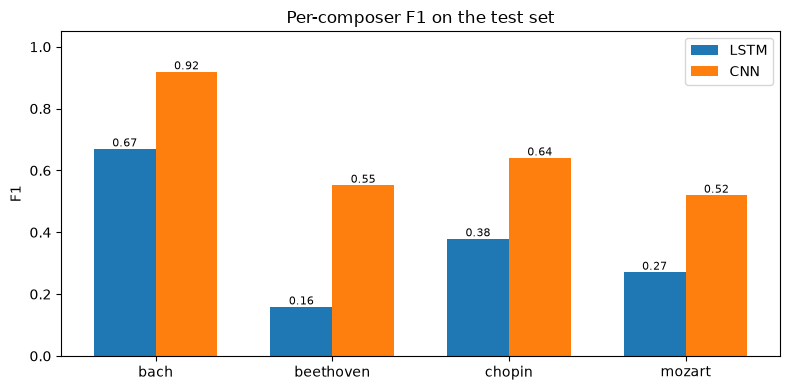

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.35
idx = np.arange(len(COMPOSERS))
for k, m in enumerate(runs):
    vals = [runs[m]["per_class"][c]["f1"] for c in COMPOSERS]
    bars = ax.bar(idx + (k - 0.5) * width, vals, width, label=m.upper())
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set(xticks=idx, xticklabels=COMPOSERS, ylabel="F1", ylim=(0, 1.05),
       title="Per-composer F1 on the test set")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "per_class_f1.png", dpi=120)
plt.show()

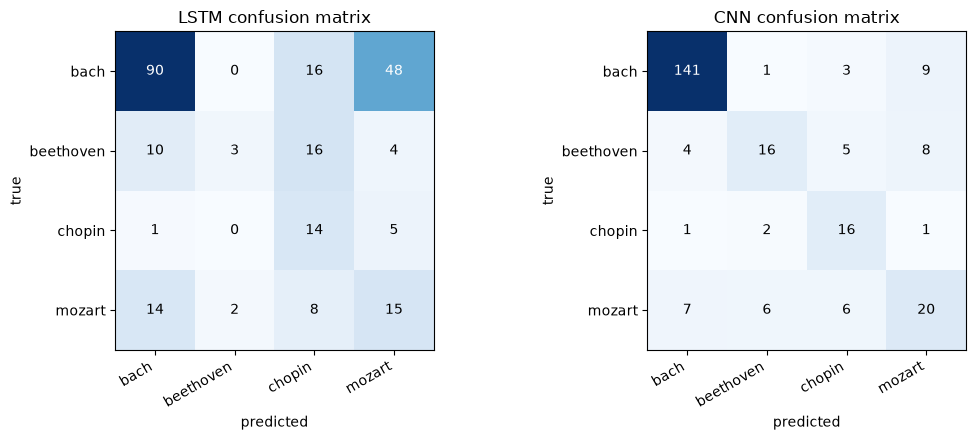

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, m in zip(axes, runs):
    cm = np.asarray(runs[m]["confusion_matrix"])
    ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(4), yticks=range(4), xticklabels=COMPOSERS,
           yticklabels=COMPOSERS, xlabel="predicted", ylabel="true",
           title=f"{m.upper()} confusion matrix")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    thresh = cm.max() / 2
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_both.png", dpi=120)
plt.show()

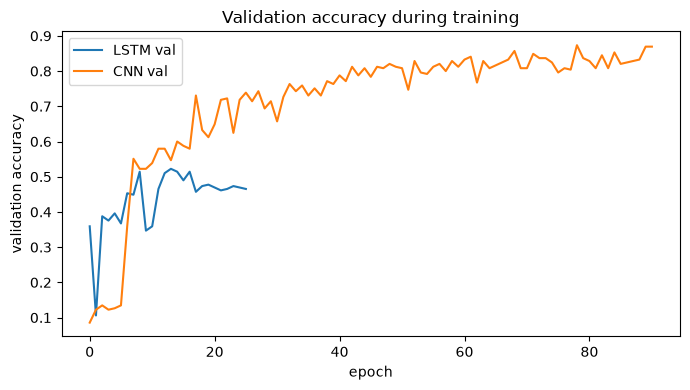

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for m in runs:
    ax.plot(runs[m]["history"]["val_accuracy"], label=f"{m.upper()} val")
ax.set(xlabel="epoch", ylabel="validation accuracy",
       title="Validation accuracy during training")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "val_accuracy_both.png", dpi=120)
plt.show()

## Reading the comparison

Fill in after running — the numbers above are what go in the report. Things to look at:

- **Accuracy vs the 0.63 baseline.** A model that only beats it slightly is mostly predicting bach.
- **Macro vs weighted recall.** A big gap means the minority composers (chopin, beethoven) are being missed and the score is riding on bach.
- **Which confusions dominate.** Beethoven/Mozart mixups are a period-style problem; anything/bach mixups are a class-imbalance problem.
- **Where the two models disagree per class.** If the LSTM wins on one composer and the CNN on another, that argues the note sequence and the piano roll are carrying different information, and an ensemble is the cheap next step.